In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

df = pd.read_csv('placement_predict_50k (5).csv')
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
df.head()

,studentid,gender,city,collegetier,stream,specialisation,hostel,historyofbacklogs,sgpa_sem1,sgpa_sem2,...,certifications,publications,aptitudetestscore,softskillsrating,codingtestscore,mockinterviewscore,extracurricular,cgpa_tier,placementstatus,isanomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [3]:
print(df.shape)
df.info()
df.describe(include='all')

(50000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   studentid           50000 non-null  int64  
 1   gender              50000 non-null  object 
 2   city                50000 non-null  object 
 3   collegetier         50000 non-null  object 
 4   stream              50000 non-null  object 
 5   specialisation      50000 non-null  object 
 6   hostel              50000 non-null  object 
 7   historyofbacklogs   50000 non-null  object 
 8   sgpa_sem1           50000 non-null  float64
 9   sgpa_sem2           50000 non-null  float64
 10  sgpa_sem3           50000 non-null  float64
 11  sgpa_sem4           50000 non-null  float64
 12  sgpa_sem5           50000 non-null  float64
 13  sgpa_sem6           50000 non-null  float64
 14  sgpa_sem7           50000 non-null  float64
 15  sgpa_sem8           50000 non-null  float

,studentid,gender,city,collegetier,stream,specialisation,hostel,historyofbacklogs,sgpa_sem1,sgpa_sem2,...,certifications,publications,aptitudetestscore,softskillsrating,codingtestscore,mockinterviewscore,extracurricular,cgpa_tier,placementstatus,isanomaly
count,50000.000000,50000,50000,50000,50000,50000,50000,50000,50000.000000,50000.000000,...,50000.00000,50000.00000,45971.000000,46474.000000,47024.000000,45043.000000,50000,50000,50000.000000,50000.000000
unique,NaN,2,9,3,6,4,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,4,NaN,NaN
top,NaN,Male,Jaipur,Tier2,CS,AI,No,No,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Medium,NaN,NaN
freq,NaN,28839,5638,27510,12044,12752,27581,39015,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,29865,23994,NaN,NaN
mean,25000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.192965,7.225781,...,2.25672,0.50968,64.857051,6.487525,59.868544,64.873778,NaN,NaN,0.474980,0.024060
std,14433.901067,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.055940,1.054930,...,1.52169,0.61964,15.911474,1.594496,18.984310,15.962862,NaN,NaN,0.499379,0.153237
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,4.000000,...,0.00000,0.00000,2.300000,0.080000,0.000000,0.000000,NaN,NaN,0.000000,0.000000
25%,12500.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.480000,6.520000,...,1.00000,0.00000,54.200000,5.410000,47.000000,54.000000,NaN,NaN,0.000000,0.000000
50%,25000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.200000,7.230000,...,2.00000,0.00000,64.900000,6.490000,60.100000,64.900000,NaN,NaN,0.000000,0.000000
75%,37500.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.910000,7.950000,...,3.00000,1.00000,75.800000,7.590000,72.900000,75.800000,NaN,NaN,1.000000,0.000000


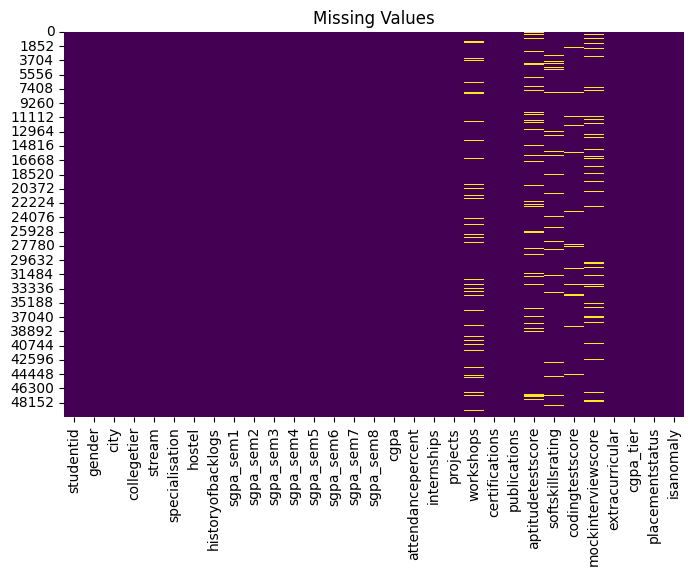

In [4]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title('Missing Values')
plt.show()

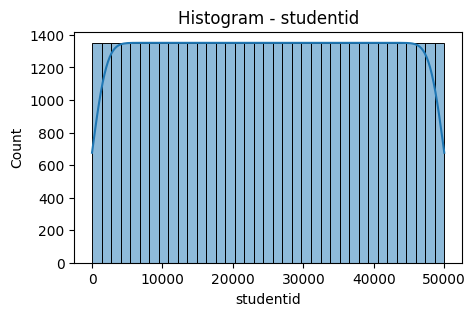

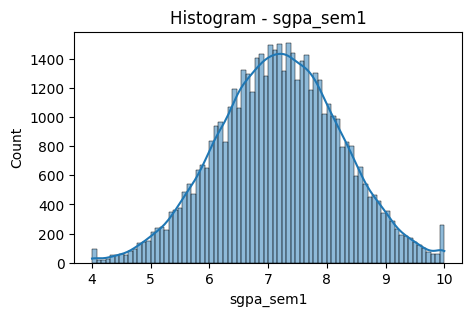

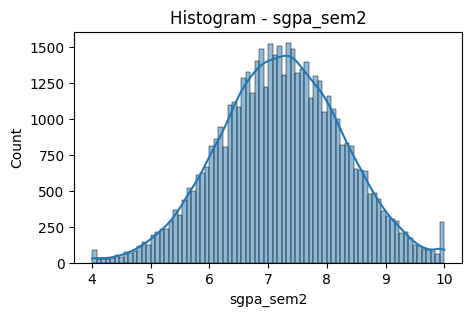

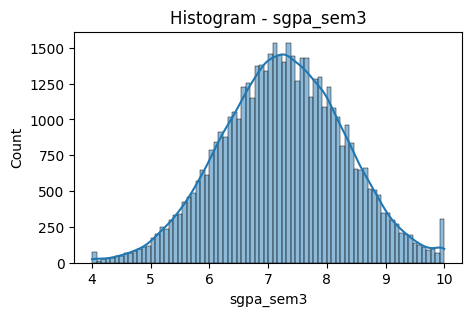

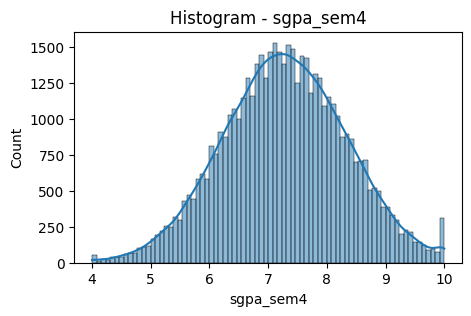

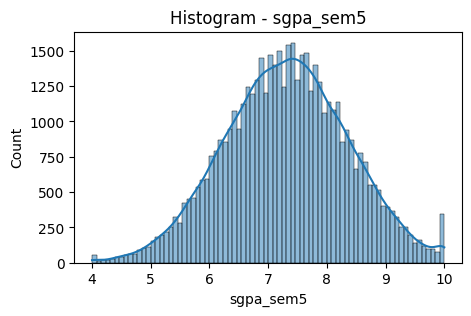

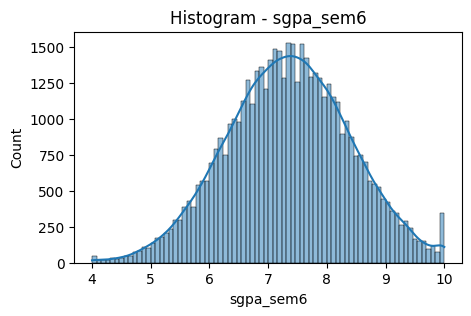

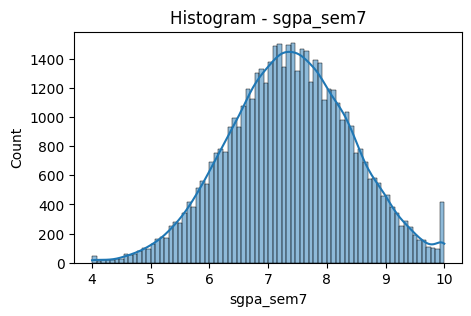

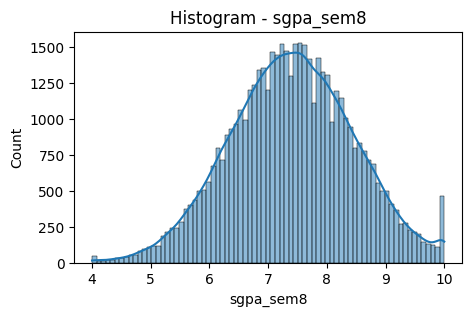

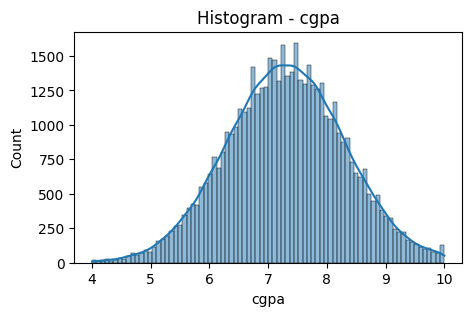

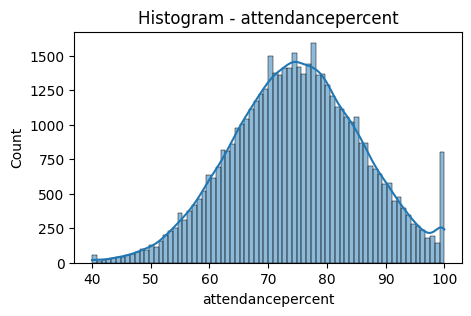

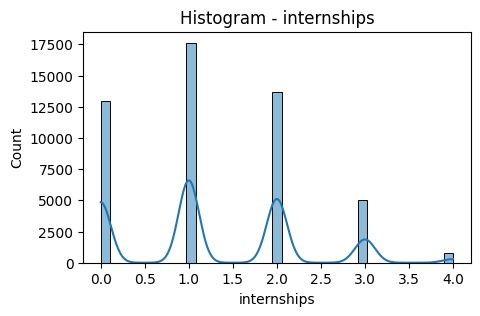

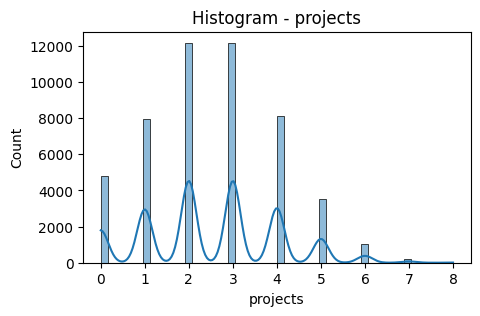

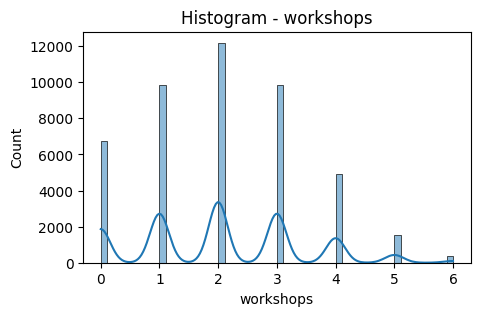

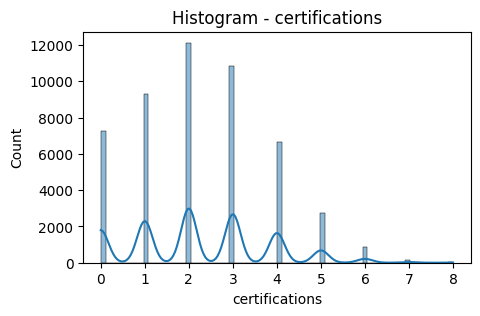

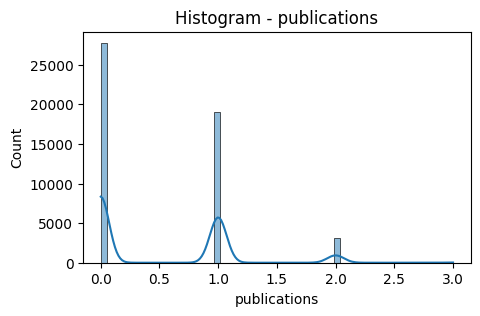

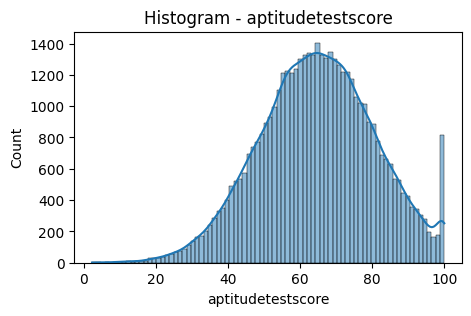

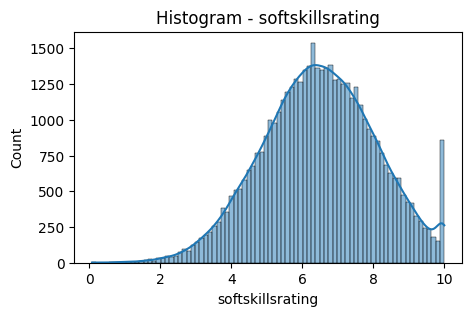

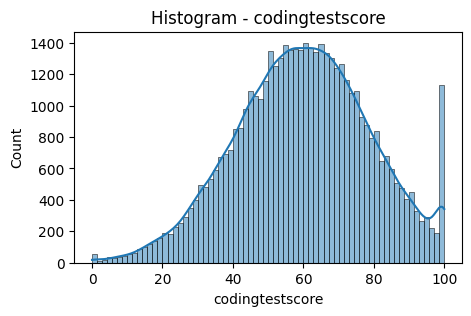

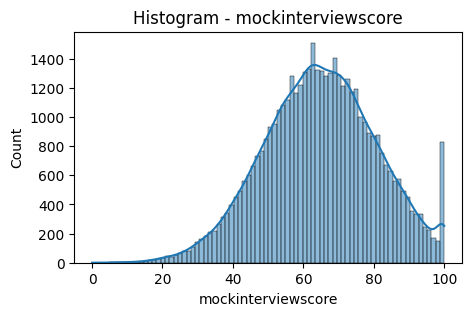

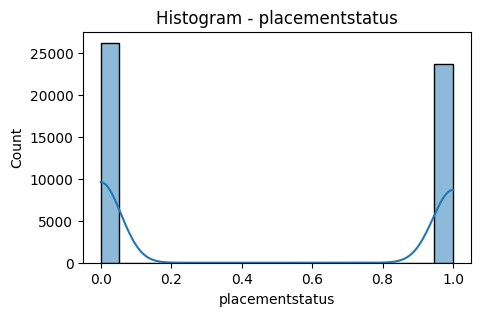

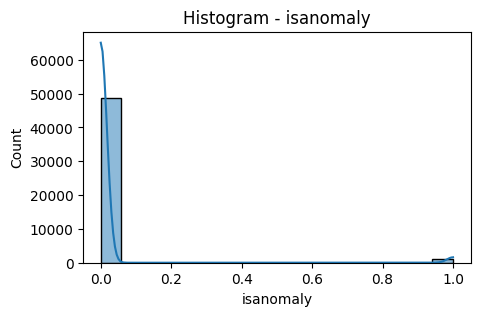

In [5]:
num=df.select_dtypes(include=np.number).columns
for col in num:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram - {col}')
    plt.show()

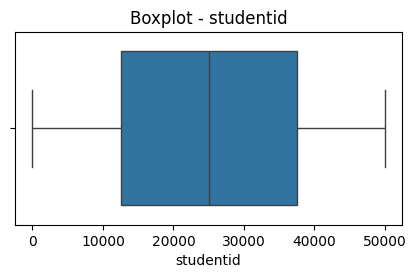

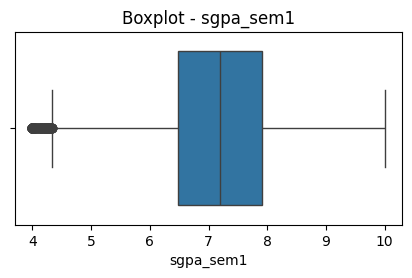

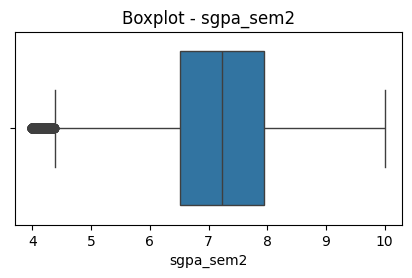

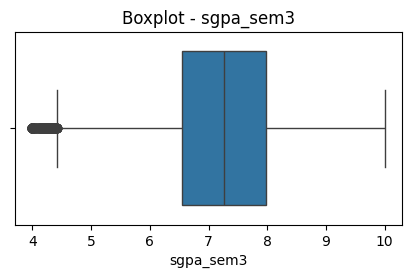

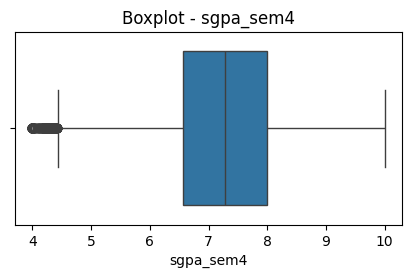

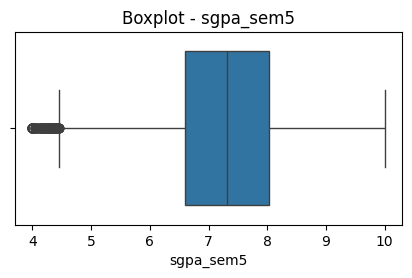

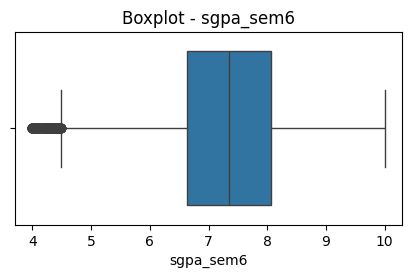

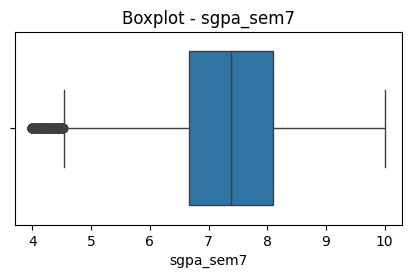

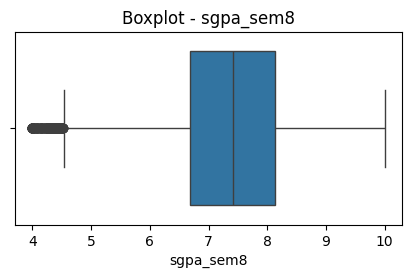

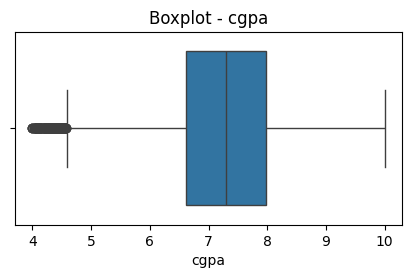

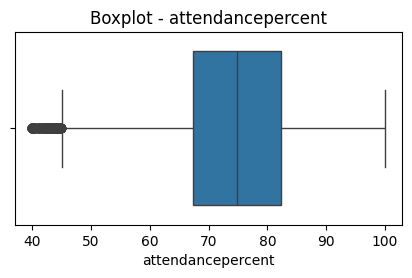

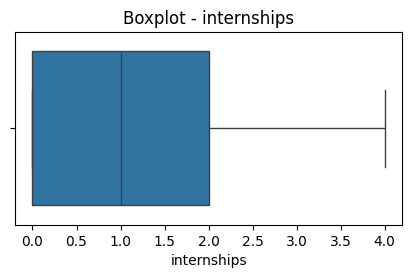

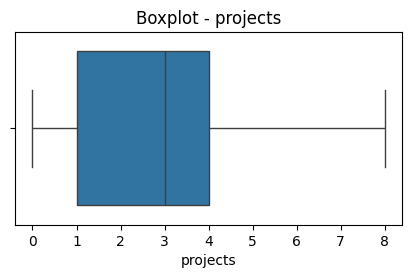

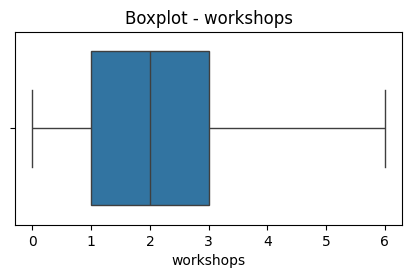

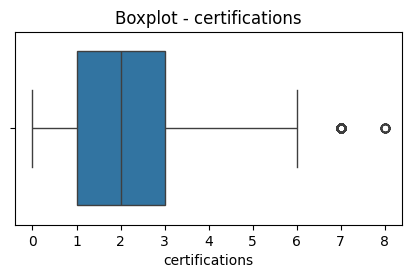

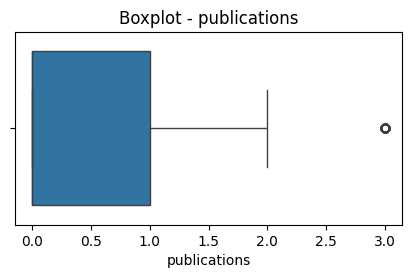

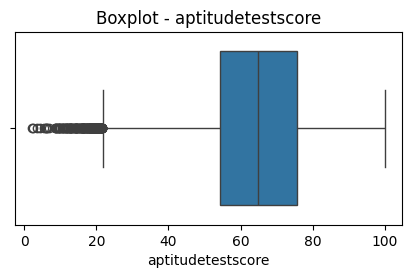

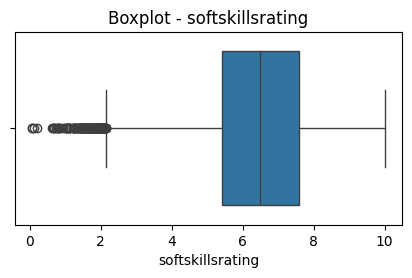

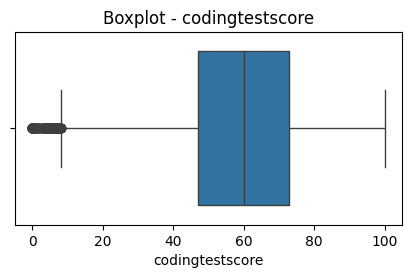

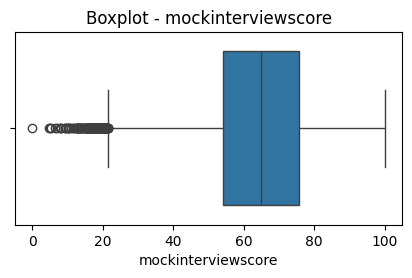

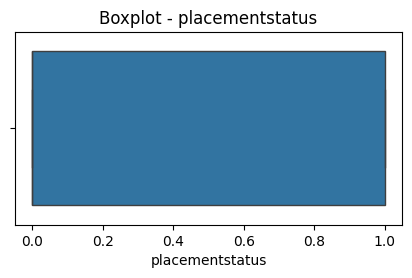

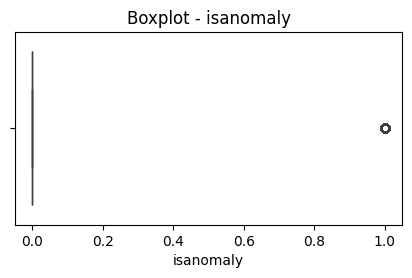

In [6]:
for col in num:
    plt.figure(figsize=(5,2.5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

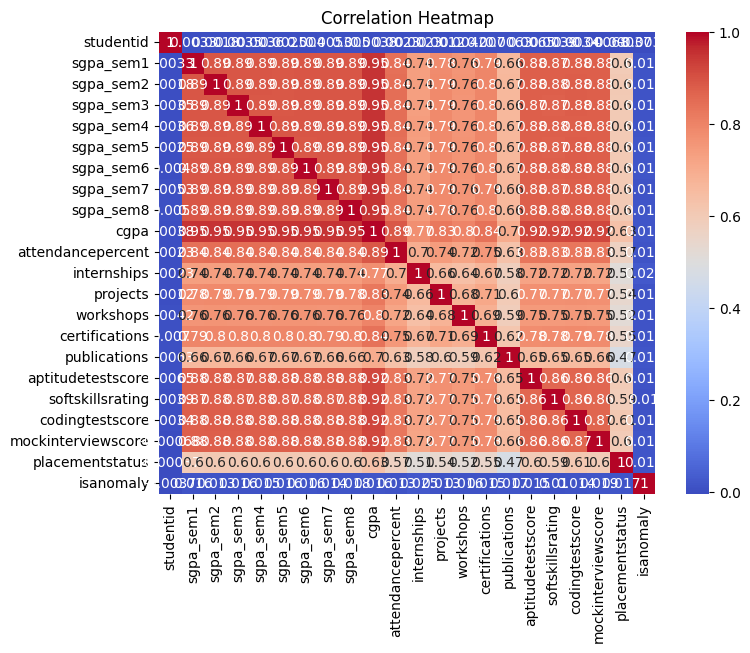

In [7]:
if len(num)>1:
    plt.figure(figsize=(8,6))
    sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

In [11]:
with PdfPages('EDA_Report_Alternative.pdf') as pdf:
    plt.figure(figsize=(8,5))
    sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
    plt.title('Missing Values')
    pdf.savefig()
    plt.close()
    for col in num:
        plt.figure(figsize=(5,3))
        sns.histplot(df[col],kde=True)
        plt.title(col)
        pdf.savefig()
        plt.close()
print('PDF report generated.')

PDF report generated.
